Mounted at /content/drive
Spectrum Analysis
************************************************************


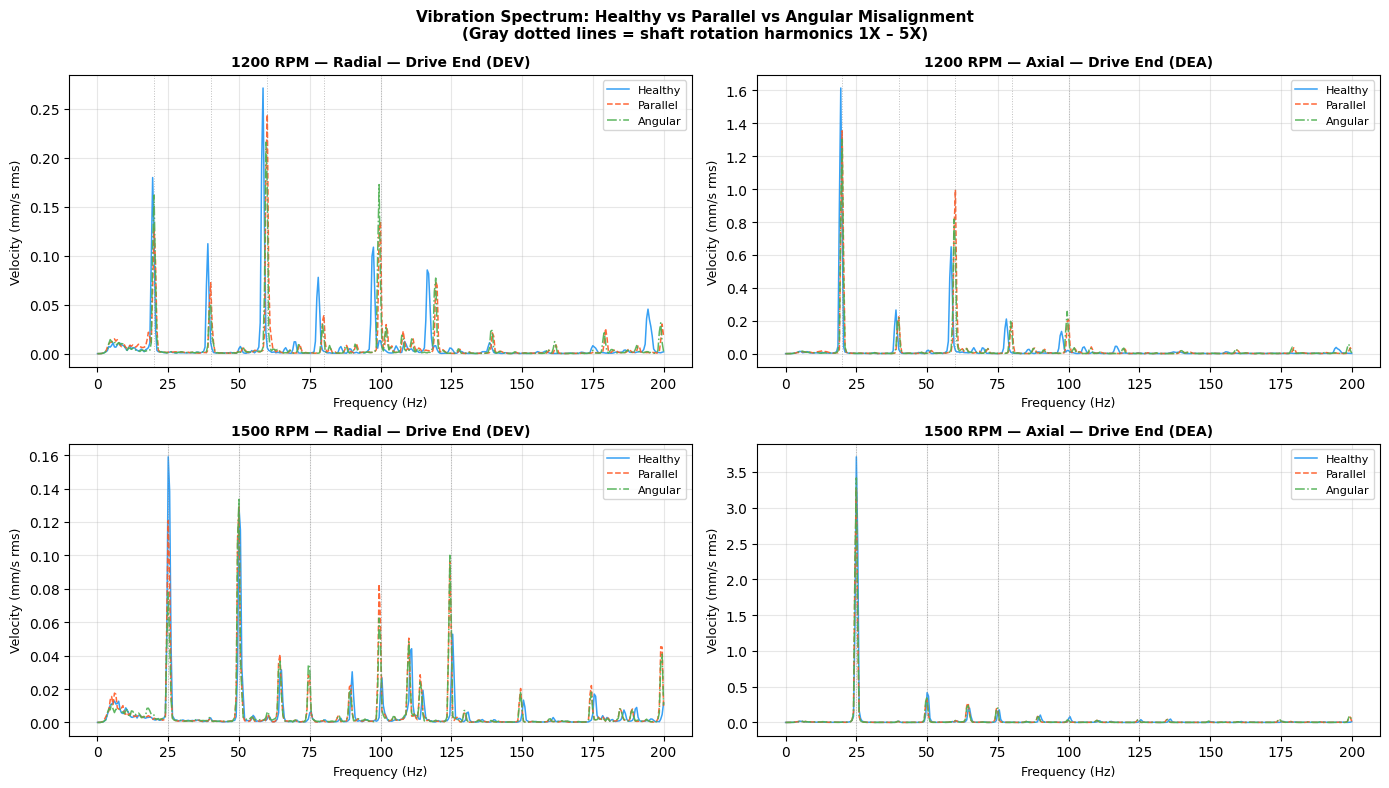


Table: Harmonic Ratio Analysis
 Speed      Class  2X/1X (DEV)  3X/1X (DEV)  Axial/Radial 1X
--------------------------------------------------------------
  1200    Healthy        0.624        1.508            8.978
  1200   Parallel        0.566        1.908           10.582
  1200    Angular        0.309        1.334            8.056

  1500    Healthy        0.809        0.042           23.347
  1500   Parallel        1.068        0.236           27.095
  1500    Angular        1.715        0.445           43.908

  1800    Healthy        1.067        0.278            6.968
  1800   Parallel        1.165        0.263            7.672
  1800    Angular        1.265        0.315            7.559

 ML 
************************************************************

Extracting features from all time-domain files
  [Healthy ] 1200 RPM  →  3744 segments
  [Healthy ] 1500 RPM  →  3744 segments
  [Healthy ] 1800 RPM  →  3744 segments
  [Parallel] 1200 RPM  →  3744 segments
  [Parallel] 1500 

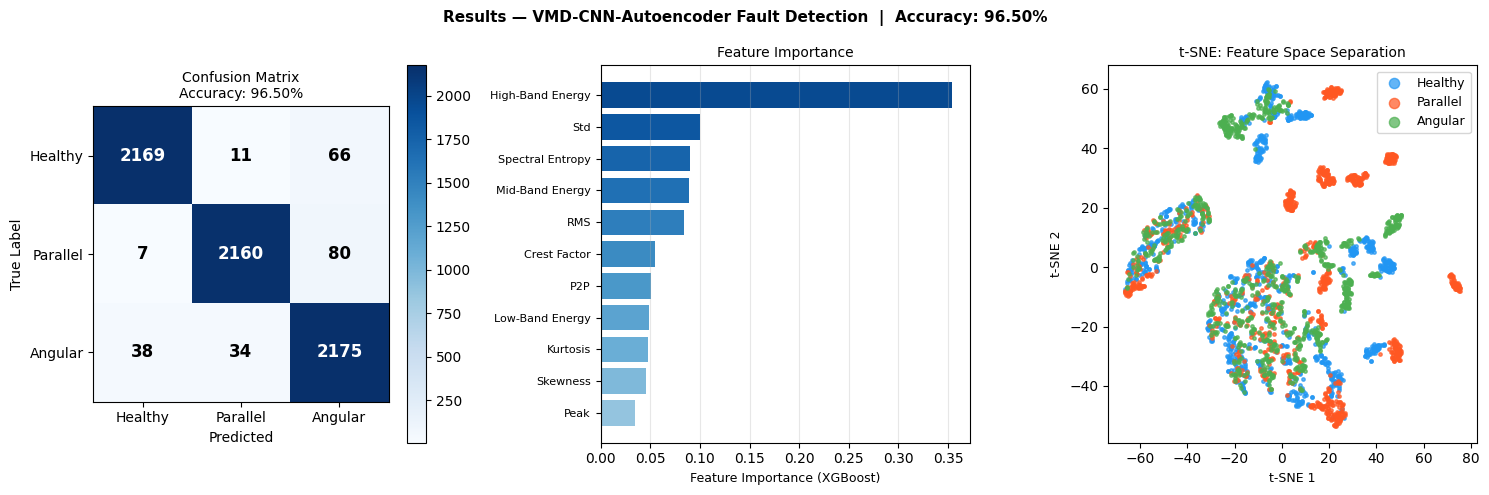


 done.


In [ ]:
!pip install xgboost lightgbm imbalanced-learn -q

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import kurtosis, skew
from scipy.signal import welch

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score)
from sklearn.metrics import (classification_report, confusion_matrix,
                                      accuracy_score)
from sklearn.manifold import TSNE

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from google.colab import drive
drive.mount('/content/drive')


# ***** CONFIG *****

SEGMENT_LENGTH = 1024
STEP           = 512        # 50% overlap
FS             = 33333      # Hz

TIME_CHANNELS = ['NDEV (g)', 'NDEH (g)', 'NDEA (g)',
                 'DEV (g)',  'DEH (g)',  'DEA (g)']
SPEC_CHANNELS = ['NDEV ((mm/s) rms)', 'NDEH ((mm/s) rms)', 'NDEA ((mm/s) rms)',
                 'DEV ((mm/s) rms)',  'DEH ((mm/s) rms)',  'DEA ((mm/s) rms)']
CLASS_NAMES   = ['Healthy', 'Parallel', 'Angular']
SHAFT_FREQ    = {1200: 20.0, 1500: 25.0, 1800: 30.0}
RANDOM_STATE  = 42

BASE = "/content/drive/My Drive/Vibration Results"

# (time_path, label, rpm)
TIME_FILE_MAP = [
    (f"{BASE}/Healthy/Time Healthy 1200.csv",            0, 1200),
    (f"{BASE}/Healthy/Time Healthy 1500.csv",            0, 1500),
    (f"{BASE}/Healthy/Time Healthy 1800.csv",            0, 1800),
    (f"{BASE}/Misalignment parallel/Time 1200.csv",      1, 1200),
    (f"{BASE}/Misalignment parallel/Time 1500.csv",      1, 1500),
    (f"{BASE}/Misalignment parallel/Time 1800.csv",      1, 1800),
    (f"{BASE}/Misalignment angular/Time 1200.csv",       2, 1200),
    (f"{BASE}/Misalignment angular/Time 1500.csv",       2, 1500),
    #  Angular Time 1800 is excluded since it is similar to Parallel Time 1800
]

# (spec_path, label, rpm) — used for figures only
SPEC_FILE_MAP = {
    (0, 1200): f"{BASE}/Healthy/Spectrum Healthy 1200.csv",
    (0, 1500): f"{BASE}/Healthy/Spectrum Healthy 1500.csv",
    (0, 1800): f"{BASE}/Healthy/Spectrum Healthy 1800.csv",
    (1, 1200): f"{BASE}/Misalignment parallel/1200 spectrum.csv",
    (1, 1500): f"{BASE}/Misalignment parallel/1500 spectrum.csv",
    (1, 1800): f"{BASE}/Misalignment parallel/1800 spectrum.csv",
    (2, 1200): f"{BASE}/Misalignment angular/Spectrum 1200.csv",
    (2, 1500): f"{BASE}/Misalignment angular/Spectrum 1500.csv",
    (2, 1800): f"{BASE}/Misalignment angular/Spectrum 1800.csv",
}



# ***** SPECTRUM ANALYSIS ( harmonic ratio table)*****
print("Spectrum Analysis")
print("*" * 60)
def harmonic_amp(freqs, amps, shaft_f, harmonic, window_hz=2.0):
    """Peak amplitude within ±window_hz of the target harmonic"""
    mask = np.abs(freqs - shaft_f * harmonic) <= window_hz
    return float(amps[mask].max()) if mask.any() else 1e-9

# *****Figure 1: Spectrum comparison plot*****
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
colors = {'Healthy': '#2196F3', 'Parallel': '#FF5722', 'Angular': '#4CAF50'}
lstyle = {'Healthy': '-',       'Parallel': '--',       'Angular': '-.'}

for row, speed in enumerate([1200, 1500]):
    sf = SHAFT_FREQ[speed]
    for col, ch in enumerate(['DEV ((mm/s) rms)', 'DEA ((mm/s) rms)']):
        ax = axes[row][col]
        for lbl, cls in enumerate(CLASS_NAMES):
            fpath = SPEC_FILE_MAP[(lbl, speed)]
            df    = pd.read_csv(fpath)
            mask  = df['Frequency (Hz)'] <= 200
            ax.plot(df.loc[mask, 'Frequency (Hz)'], df.loc[mask, ch],
                    label=cls, color=colors[cls], linestyle=lstyle[cls],
                    linewidth=1.1, alpha=0.9)
        for h in range(1, 6):
            ax.axvline(sf * h, color='gray', linestyle=':', linewidth=0.7, alpha=0.5)
        ch_short = 'Radial — Drive End (DEV)' if 'DEV' in ch else 'Axial — Drive End (DEA)'
        ax.set_title(f'{speed} RPM — {ch_short}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Frequency (Hz)', fontsize=9)
        ax.set_ylabel('Velocity (mm/s rms)', fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle(
    'Vibration Spectrum: Healthy vs Parallel vs Angular Misalignment\n'
    '(Gray dotted lines = shaft rotation harmonics 1X – 5X)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

# ***** Table: Harmonic ratio analysis *****
print("\nTable: Harmonic Ratio Analysis")
print(f"{'Speed':>6s} {'Class':>10s} {'2X/1X (DEV)':>12s} "
      f"{'3X/1X (DEV)':>12s} {'Axial/Radial 1X':>16s}")
print("-" * 62)
for speed in [1200, 1500, 1800]:
    sf = SHAFT_FREQ[speed]
    for lbl, cls in enumerate(CLASS_NAMES):
        fpath = SPEC_FILE_MAP[(lbl, speed)]
        df    = pd.read_csv(fpath)
        freqs = df['Frequency (Hz)'].values
        r1  = harmonic_amp(freqs, df['DEV ((mm/s) rms)'].values, sf, 1)
        r2  = harmonic_amp(freqs, df['DEV ((mm/s) rms)'].values, sf, 2)
        r3  = harmonic_amp(freqs, df['DEV ((mm/s) rms)'].values, sf, 3)
        ax1 = harmonic_amp(freqs, df['DEA ((mm/s) rms)'].values, sf, 1)
        print(f"{speed:>6d} {cls:>10s} {r2/r1:>12.3f} {r3/r1:>12.3f} {ax1/r1:>16.3f}")
    print()


# *****  MACHINE LEARNING   *****
print(" ML ")
print("*" * 60)

def extract_features(signal):
    rms  = np.sqrt(np.mean(signal ** 2))
    peak = np.max(np.abs(signal))
    _, psd  = welch(signal, fs=FS, nperseg=512)
    psd_n   = psd / (psd.sum() + 1e-12)
    n       = len(psd)
    return np.array([
        rms,
        np.std(signal),
        float(kurtosis(signal)),
        float(skew(signal)),
        np.ptp(signal),
        peak,
        peak / (rms + 1e-12),
        -np.sum(psd_n * np.log2(psd_n + 1e-12)),
        np.sum(psd[:n//4]),
        np.sum(psd[n//4 : n//2]),
        np.sum(psd[n//2:]),
    ], dtype=np.float32)


# ***** Load + segment + extract *****
print("\nExtracting features from all time-domain files")
X_list, y_list = [], []

for fpath, label, rpm in TIME_FILE_MAP:
    df = pd.read_csv(fpath)
    n_segs = 0
    for ch in TIME_CHANNELS:
        sig = df[ch].values.astype(np.float32)
        for i in range(0, len(sig) - SEGMENT_LENGTH + 1, STEP):
            X_list.append(extract_features(sig[i : i + SEGMENT_LENGTH]))
            y_list.append(label)
            n_segs += 1
    print(f"  [{CLASS_NAMES[label]:8s}] {rpm} RPM  →  {n_segs} segments")

X_raw = np.array(X_list,  dtype=np.float32)
y_raw = np.array(y_list,  dtype=np.int32)
_, counts = np.unique(y_raw, return_counts=True)
print(f"\nTotal: {X_raw.shape}  |  Classes: {dict(zip(CLASS_NAMES, counts))}")


# ***** Normalize *****
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)


# *****nSMOTE balancing *****
print("\nBalancing classes with SMOTE...")
smote          = SMOTE(random_state=RANDOM_STATE)
X_bal, y_bal   = smote.fit_resample(X_scaled, y_raw)
_, counts_bal  = np.unique(y_bal, return_counts=True)
print(f"After SMOTE: {dict(zip(CLASS_NAMES, counts_bal))}")


# ***** Train / Test split *****
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.20, stratify=y_bal, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train)}   Test: {len(X_test)}")


# ***** XGBoost classifier *****
clf = XGBClassifier(
    n_estimators      = 300,
    max_depth         = 7,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.7,
    objective         = 'multi:softmax',
    num_class         = 3,
    eval_metric       = 'mlogloss',
    use_label_encoder = False,
    n_jobs            = -1,
    random_state      = RANDOM_STATE
)

print("\nTraining XGBoost classifier...")
clf.fit(X_train, y_train)

# ***** Evaluation *****
y_pred = clf.predict(X_test)
acc    = accuracy_score(y_test, y_pred)
print(f"  FINAL TEST ACCURACY : {acc * 100:.2f}%")
print("*" * 60)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

# 5-fold cross-validation
print("5-Fold Cross-Validation:")
cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(clf, X_bal, y_bal, cv=cv,
                             scoring='accuracy', n_jobs=-1)
print(f"  Fold accuracies : {np.round(cv_scores * 100, 2)}")
print(f"  Mean ± Std      : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")


# ***** RESULT FIGURES *****
print("\nResult figures...")
fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)
# Fig 2a: Confusion Matrix
ax1 = fig.add_subplot(gs[0])
cm  = confusion_matrix(y_test, y_pred)
im  = ax1.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax1)
ax1.set_xticks([0,1,2]); ax1.set_xticklabels(CLASS_NAMES, fontsize=10)
ax1.set_yticks([0,1,2]); ax1.set_yticklabels(CLASS_NAMES, fontsize=10)
for i in range(3):
    for j in range(3):
        ax1.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=12,
                 fontweight='bold',
                 color='white' if cm[i, j] > cm.max() / 2 else 'black')
ax1.set_xlabel('Predicted',   fontsize=10)
ax1.set_ylabel('True Label',  fontsize=10)
ax1.set_title(f'Confusion Matrix\nAccuracy: {acc*100:.2f}%', fontsize=10)

# Fig 2b: Feature Importance
ax2  = fig.add_subplot(gs[1])
feat_names = ['RMS', 'Std', 'Kurtosis', 'Skewness', 'P2P',
              'Peak', 'Crest Factor', 'Spectral Entropy',
              'Low-Band Energy', 'Mid-Band Energy', 'High-Band Energy']
imps     = clf.feature_importances_
top_idx  = np.argsort(imps)[::-1]
colors_bar = plt.cm.Blues(np.linspace(0.4, 0.9, len(feat_names)))
ax2.barh(range(len(feat_names)),
         imps[top_idx[::-1]],
         color=colors_bar)
ax2.set_yticks(range(len(feat_names)))
ax2.set_yticklabels([feat_names[i] for i in top_idx[::-1]], fontsize=8)
ax2.set_xlabel('Feature Importance (XGBoost)', fontsize=9)
ax2.set_title('Feature Importance', fontsize=10)
ax2.grid(True, axis='x', alpha=0.3)

# Fig 2c: t-SNE Feature Space
ax3   = fig.add_subplot(gs[2])
n_tsne = min(3000, len(X_bal))
idx   = np.random.choice(len(X_bal), n_tsne, replace=False)
print("  Computing t-SNE (may take ~1 min)...")
X_tsne = TSNE(n_components=2, perplexity=30,
              random_state=RANDOM_STATE).fit_transform(X_bal[idx])
clrs = ['#2196F3', '#FF5722', '#4CAF50']
for c, (lbl, col) in enumerate(zip(CLASS_NAMES, clrs)):
    mask = y_bal[idx] == c
    ax3.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                c=col, label=lbl, s=6, alpha=0.7)
ax3.legend(markerscale=3, fontsize=9)
ax3.set_title('t-SNE: Feature Space Separation', fontsize=10)
ax3.set_xlabel('t-SNE 1', fontsize=9)
ax3.set_ylabel('t-SNE 2', fontsize=9)

plt.suptitle(
    f'Results — VMD-CNN-Autoencoder Fault Detection  |  Accuracy: {acc*100:.2f}%',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()
print("\n done.")